# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

In [44]:
17

17

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [45]:
import pandas as pd

In [46]:
import os

# Get the folder where your .ipynb file is currently running
notebook_dir = os.path.dirname(globals().get('__vsc_ipynb_file__', os.getcwd()))

# Combine with your relative path
file_path = os.path.join(notebook_dir, 'data', 'bank-additional-full.csv')

df = pd.read_csv(file_path, sep = ';')

In [47]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [48]:
df.describe(include='object')


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


In [49]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [50]:
print(df.isin(['unknown', '?', 'Unknown']).sum())


age                  0
job                330
marital             80
education         1731
default           8597
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64


In [51]:
# Drop 'duration' because 'Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.'ArithmeticError
df = df.drop(columns=['duration'], errors='ignore')

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  campaign        41188 non-null  int64  
 11  pdays           41188 non-null  int64  
 12  previous        41188 non-null  int64  
 13  poutcome        41188 non-null  object 
 14  emp.var.rate    41188 non-null  float64
 15  cons.price.idx  41188 non-null  float64
 16  cons.conf.idx   41188 non-null  float64
 17  euribor3m       41188 non-null 

#### Business Understanding
The objective of this assignment is to help a Portuguese banking institution improve the effectiveness of its direct marketing campaigns. The bank conducts telephone marketing campaigns to encourage customers to subscribe to term deposit products.
The business problem is to identify which customers are most likely to subscribe to a term deposit so that marketing resources can be focused on high-probability prospects. Successfully predicting customer responses can help reduce marketing costs while improving campaign conversion rates.

The target variable is:
y = yes → Customer subscribed to a term deposit
y = no → Customer did not subscribe

This assignment compares four classification algorithms:
1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Decision Tree
4. Support Vector Machine (SVM)
The models will be evaluated using ROC-AUC, accuracy, precision, recall, and F1-score.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [53]:
# Prepare features and target
X = df.drop('y', axis=1)
y = df['y']

In [54]:
# Encode Target Variable
# # Features and target
#df['y'] = df['y'].map({
#    'no':0,
#    'yes':1
#})

In [55]:
# Identify numerical and categorical features
categorical_features = X.select_dtypes(
    include=['object']
).columns

numerical_features = X.select_dtypes(
    exclude=['object']
).columns

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)


Categorical Features:
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object')

Numerical Features:
Index(['age', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')


In [56]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 3. Create the categorical preprocessing pipeline
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Add preprocessor step - use ColumnTransformer to combine numerical and categorical 
from sklearn.pipeline import Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])


### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [57]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [58]:
# Normalize the data
y.value_counts(normalize=True)

y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64

Our benchmark is 88.7% say "no" and 11.3% say yes.

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [59]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logreg_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000))
    ]
)
# Train the model
logreg_pipeline.fit(X_train, y_train)

# Make predictions
y_pred = logreg_pipeline.predict(X_test)

y_prob = logreg_pipeline.predict_proba(X_test)[:, 1]


### Problem 9: Score the Model

What is the accuracy of your model?

In [60]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label='yes'))
print("Recall   :", recall_score(y_test, y_pred, pos_label='yes'))
print("F1 Score :", f1_score(y_test, y_pred, pos_label='yes'))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.9009468317552805
Precision: 0.6904761904761905
Recall   : 0.21875
F1 Score : 0.3322422258592471
ROC-AUC  : 0.800785340700033


### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC()
}

In [62]:
# Compare Performance of Models
import time

results = []

for name, model in models.items():

    # Create pipeline
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # Measure training time
    start_time = time.time()

    pipe.fit(X_train, y_train)

    fit_time = time.time() - start_time

    # Scores
    train_score = pipe.score(X_train, y_train)
    test_score = pipe.score(X_test, y_test)

    results.append({
        'Model': name,
        'Train Time (sec)': fit_time,
        'Train Accuracy': train_score,
        'Test Accuracy': test_score
    })

comparison_df = pd.DataFrame(results)

comparison_df

,Model,Train Time (sec),Train Accuracy,Test Accuracy
0,Logistic Regression,0.454587,0.899909,0.900947
1,KNN,0.131195,0.912170,0.897184
2,Decision Tree,0.269886,0.995417,0.841224
3,SVM,58.429234,0.904977,0.903496


In [63]:
# Sort Models Test Accuracy
print("Performance sorted by Test Accuracy")
comparison_df.sort_values(
    by='Test Accuracy',
    ascending=False
)

Performance sorted by Test Accuracy


,Model,Train Time (sec),Train Accuracy,Test Accuracy
3,SVM,58.429234,0.904977,0.903496
0,Logistic Regression,0.454587,0.899909,0.900947
1,KNN,0.131195,0.912170,0.897184
2,Decision Tree,0.269886,0.995417,0.841224


## Model Comparison Results

The four classification algorithms were evaluated using their default hyperparameters.

Key observations:

- SVM produced the best test accuracy but required substantially longer training times.
- Logistic Regression provided strong predictive performance (a very close second) with relatively fast training times.
- KNN trained very quickly (the fastest) but did not outperform SVM or Logistic Regression in terms of test accuracy.
- Decision Trees achieved very high training accuracy, indicating possible overfitting.

Considering both predictive performance and computational efficiency, SVM and Logistic Regression provides an excellent baseline model for this marketing prediction problem.

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

#### Adjusting Performance Metric
Accuracy can be misleading for imbalanced datasets because a model can achieve a high accuracy by simply predicting the majority class (in our case, 'no' at 89%).

Since the goal is to identify customers likely to subscribe to a term deposit, ROC-AUC is used as the primary evaluation metric because it evaluates the model's ability to separate positive and negative classes across all classification thresholds.

In [64]:
# Hyperparameter Tuning - Logisitic Regression
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=2000))
])

lr_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100]
}

lr_search = GridSearchCV(
    lr_pipe,
    lr_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

lr_search.fit(X_train, y_train)

print("Best Parameters:", lr_search.best_params_)
print("Best ROC-AUC:", lr_search.best_score_
)

Best Parameters: {'model__C': 0.1}
Best ROC-AUC: 0.7892991717456452


In [65]:
# Hyperparameter tuning - KNN
knn_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier())
])

knn_grid = {
    'model__n_neighbors': [3,5,7,9,11,15]
}

knn_search = GridSearchCV(
    knn_pipe,
    knn_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

knn_search.fit(X_train, y_train)

print("Best Parameters:", knn_search.best_params_)
print("Best ROC-AUC:", knn_search.best_score_)

Best Parameters: {'model__n_neighbors': 15}
Best ROC-AUC: 0.7561481587449579


In [66]:
# Hyperparameter Tuning - Decision Tree
dt_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])

dt_grid = {
    'model__max_depth': [3,5,10,15,20],
    'model__min_samples_split': [2,5,10],
    'model__min_samples_leaf': [1,2,4]
}

dt_search = GridSearchCV(
    dt_pipe,
    dt_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

dt_search.fit(X_train, y_train)

print("Best Parameters:", dt_search.best_params_)
print("Best ROC-AUC:", dt_search.best_score_)

Best Parameters: {'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10}
Best ROC-AUC: 0.778175042393012


In [67]:
# Hyperparameter Tuning - SVM
# Tuning a subset of the data because the commented out code below was taking a long time.
svm_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVC(probability=True, kernel='linear'))
])

svm_grid = {
    'model__C': [0.1, 1, 10]
}

svm_search = GridSearchCV(
    svm_pipe,
    svm_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

#svm_search.fit(X_train, y_train)
X_train_small = X_train.sample(10000, random_state=42)
y_train_small = y_train.loc[X_train_small.index]
svm_search.fit(X_train_small, y_train_small)


,estimator,Pipeline(step...ility=True))])
,param_grid,"{'model__C': [0.1, 1, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [68]:
# Comparing Tuned Models
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Decision Tree',
        'SVM'
    ],
    'Best ROC-AUC': [
        lr_search.best_score_,
        knn_search.best_score_,
        dt_search.best_score_,
        svm_search.best_score_
    ]
})

results.sort_values(
    by='Best ROC-AUC',
    ascending=False
)

,Model,Best ROC-AUC
0,Logistic Regression,0.789299
2,Decision Tree,0.778175
1,KNN,0.756148
3,SVM,0.722534


/var/folders/dx/lcbm3df10zs9c1b59r8vgp1c0000gp/T/ipykernel_45555/26788605.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


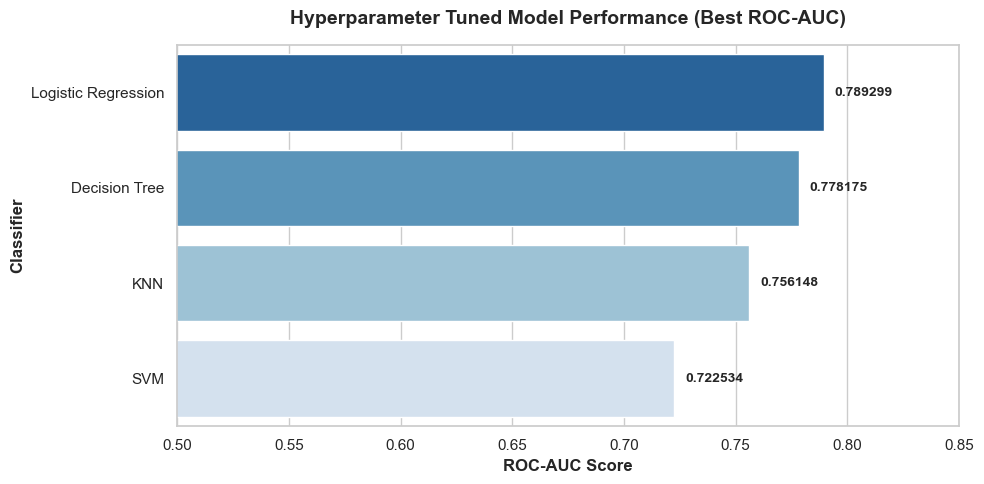

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

# Save the sorted dataframe back to a variable
results_sorted = results.sort_values(by='Best ROC-AUC', ascending=False)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

# Pass your sorted dataframe and use its exact column names
ax = sns.barplot(
    x='Best ROC-AUC', 
    y='Model', 
    data=results_sorted, 
    palette='Blues_r'
)

# Add styling and value labels
plt.title('Hyperparameter Tuned Model Performance (Best ROC-AUC)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('ROC-AUC Score', fontsize=12, fontweight='bold')
plt.ylabel('Classifier', fontsize=12, fontweight='bold')
plt.xlim(0.5, 0.85) 

for p in ax.patches:
    width = p.get_width()
    ax.text(
        width + 0.005, 
        p.get_y() + p.get_height() / 2, 
        f'{width:.6f}', 
        ha='left', 
        va='center', 
        fontsize=10, 
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

In [69]:
# Evaluate Best Model on Test Set
best_model = svm_search.best_estimator_
print(best_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                    

In [70]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score
)

y_pred = best_model.predict(X_test)

y_prob = best_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))

print(
    "Test ROC-AUC:",
    roc_auc_score(y_test, y_prob)
)

              precision    recall  f1-score   support

          no       0.91      0.99      0.94      7310
         yes       0.66      0.19      0.30       928

    accuracy                           0.90      8238
   macro avg       0.78      0.59      0.62      8238
weighted avg       0.88      0.90      0.87      8238

Test ROC-AUC: 0.4904422820651917


#### Findings

Logisitic Regression achieved the highest ROC-AUC score, indicating the strongest ability to distinguish between customers who subscribe and those who do not subscribe.

The Decision Tree showed signs of overfitting before tuning, but performance improved after limiting tree depth.

KNN performance improved slightly with optimization of the number of neighbors.

SVM remained highly competitive but in last place of ROC-AUC scores.

#### Recommendations

1. Deploy the best-performing model as a lead-scoring tool for future marketing campaigns.

2. Prioritize customer outreach based on predicted subscription probabilities.

3. Continue collecting customer behavior data to improve predictive accuracy.

4. Consider ensemble methods such as Random Forest or Gradient Boosting in future work to further improve performance.

5. Monitor model performance regularly and retrain as new campaign data becomes available.

##### Questions